In [2]:
import pandas as pd

### 1. Load the dataset using Pandas

In [3]:
df = pd.read_csv('purchase_data.csv')

In [4]:
df = pd.DataFrame(df)
df.head()

,CustomerID,Age,Gender,PurchaseAmount,Country
0,101,25.0,Male,250.0,India
1,102,NaN,Female,300.0,USA
2,103,45.0,Male,10000.0,India
3,104,22.0,Female,150.0,UK
4,105,35.0,Male,NaN,India


In [5]:
df.isnull().sum()

CustomerID        0
Age               1
Gender            0
PurchaseAmount    1
Country           0
dtype: int64

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CustomerID      5 non-null      int64  
 1   Age             4 non-null      float64
 2   Gender          5 non-null      str    
 3   PurchaseAmount  4 non-null      float64
 4   Country         5 non-null      str    
dtypes: float64(2), int64(1), str(2)
memory usage: 332.0 bytes


### 2. Handle missing values

###  Age → fill with median

In [7]:
df['Age'] = df['Age'].fillna(df['Age'].median())

### PurchaseAmount → fill with mean

In [8]:
df['PurchaseAmount'] = df['PurchaseAmount'].fillna(df['PurchaseAmount'].mean())

In [9]:
df.head()

,CustomerID,Age,Gender,PurchaseAmount,Country
0,101,25.0,Male,250.0,India
1,102,30.0,Female,300.0,USA
2,103,45.0,Male,10000.0,India
3,104,22.0,Female,150.0,UK
4,105,35.0,Male,2675.0,India


### 3. Detect outliers in PurchaseAmount using IQR method

In [10]:
q1 = df['PurchaseAmount'].quantile(0.25)
q3 = df['PurchaseAmount'].quantile(0.75)
iqr = q3 - q1
low = q1 - 1.5*iqr
high = q3 + 1.5*iqr



### 4. Remove outliers

In [11]:
df = df[(df['PurchaseAmount'] >= low) & (df['PurchaseAmount'] <= high)]

In [12]:
df.head()

,CustomerID,Age,Gender,PurchaseAmount,Country
0,101,25.0,Male,250.0,India
1,102,30.0,Female,300.0,USA
3,104,22.0,Female,150.0,UK
4,105,35.0,Male,2675.0,India


### Average purchase amount by country

In [13]:
groupbycountry = df.groupby('Country')['PurchaseAmount'].mean()
print(groupbycountry)

Country
India    1462.5
UK        150.0
USA       300.0
Name: PurchaseAmount, dtype: float64


### Total purchases by gender

In [14]:
groupbygender = df.groupby('Gender')['PurchaseAmount'].sum()
print(groupbygender)

Gender
Female     450.0
Male      2925.0
Name: PurchaseAmount, dtype: float64


In [15]:
import seaborn as sns

### 6. Create a bar chart showing purchase by country

<Axes: xlabel='Country', ylabel='PurchaseAmount'>

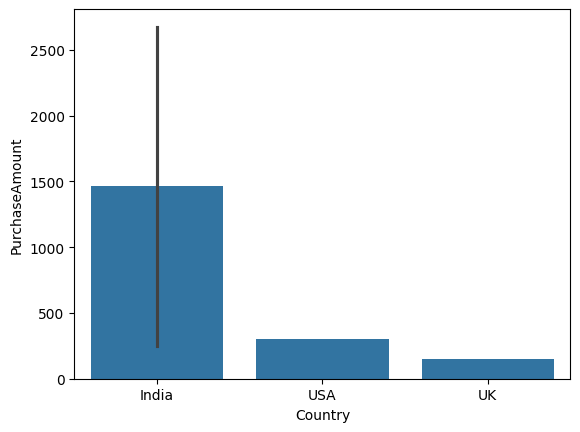

In [16]:
sns.barplot(x='Country', y='PurchaseAmount', data=df)

### Test case 2

In [17]:
df1 = pd.read_csv('synthetic_customers.csv')

In [18]:
df1.head()

,CustomerID,Age,Gender,PurchaseAmount,Country
0,201,30,Male,200,USA
1,202,28,Female,50000,Canada
2,203,27,Male,220,USA
3,204,58,Female,698,Canada
4,205,48,Female,367,UK


In [19]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   CustomerID      100 non-null    int64
 1   Age             100 non-null    int64
 2   Gender          100 non-null    str  
 3   PurchaseAmount  100 non-null    int64
 4   Country         100 non-null    str  
dtypes: int64(3), str(2)
memory usage: 4.0 KB


<Axes: xlabel='PurchaseAmount'>

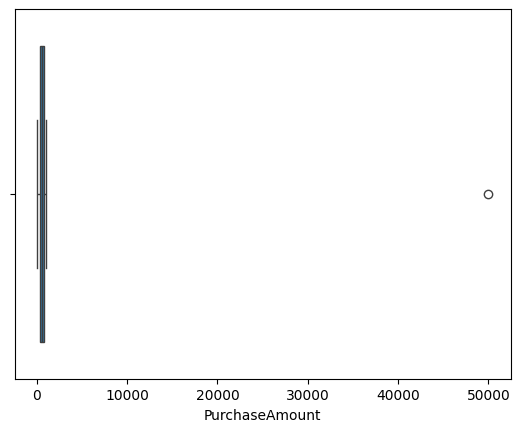

In [20]:
sns.boxplot(x=df1['PurchaseAmount'])

In [21]:
q1_1 = df1['PurchaseAmount'].quantile(0.25)
q3_1 = df1['PurchaseAmount'].quantile(0.75)

iqr_1 = q3_1 - q1_1
low_1 = q1_1 - 1.5*iqr_1
high_1 = q3_1 + 1.5*iqr_1  
outliers = df1[(df1['PurchaseAmount'] < low_1) | (df1['PurchaseAmount'] > high_1)]
df1 = df1[(df1['PurchaseAmount'] >= low_1) & (df1['PurchaseAmount'] <= high_1)]
print("detected outliers:",outliers['PurchaseAmount'].values)

df1.head()

detected outliers: [50000]


,CustomerID,Age,Gender,PurchaseAmount,Country
0,201,30,Male,200,USA
2,203,27,Male,220,USA
3,204,58,Female,698,Canada
4,205,48,Female,367,UK
5,206,34,Male,726,Germany
